# KNN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
data = pd.read_csv('preprocessed_loan_data.csv')

data.head()

,loan_percent_income,loan_int_rate,cb_person_cred_hist_length,person_age,credit_score,person_emp_exp,person_education_Associate,person_education_Bachelor,person_education_Doctorate,person_education_High School,...,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_gender,previous_loan_defaults_on_file,loan_status
0,1.000000,0.715620,0.087589,0.14898,0.250733,0.000000,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0
1,0.175824,0.401104,0.014596,0.10092,0.058291,0.000000,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,1
2,0.967033,0.512603,0.087589,0.29316,0.500570,0.162162,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0
3,0.967033,0.664705,0.014596,0.19704,0.635617,0.000000,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0
4,1.000000,0.602833,0.160582,0.24510,0.335137,0.054054,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0,0


In [3]:
#shape
data.shape

(70000, 24)

# Split the data

In [4]:
# Separate feature columns and target column
X = data.drop('loan_status', axis=1)   # All columns except the target
Y = data['loan_status']                # Target column

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20)

In [6]:
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (56000, 23)
Testing set shape: (14000, 23)


In [7]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
knn.score(X_test, y_test)

0.8777857142857143

In [9]:
correct_sum = []
for i in range(1,20):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    correct = np.sum(pred == y_test)
    correct_sum.append(correct)

In [10]:
correct_sum

[np.int64(11887),
 np.int64(12045),
 np.int64(12103),
 np.int64(12143),
 np.int64(12192),
 np.int64(12194),
 np.int64(12241),
 np.int64(12257),
 np.int64(12289),
 np.int64(12284),
 np.int64(12289),
 np.int64(12279),
 np.int64(12292),
 np.int64(12299),
 np.int64(12278),
 np.int64(12287),
 np.int64(12292),
 np.int64(12286),
 np.int64(12293)]

## Hyperparameter Tuning - GridSearchCV (KNN)

In [9]:
from sklearn.model_selection import GridSearchCV

# Grid 1
param_grid_knn_1 = {
    'n_neighbors': [11, 21, 31, 41, 51],           
    'weights': ['uniform'],         
    'metric': ['manhattan', 'euclidean'] 
}

# Grid 2
param_grid_knn_2 = {
    'n_neighbors': [61, 81, 101, 151, 201],    
    'weights': ['uniform', 'distance'], 
    'metric': ['euclidean', 'manhattan']
}

# Grid 3
param_grid_knn_3 = {
    'n_neighbors': [251, 301, 401, 501],       
    'weights': ['uniform', 'distance'],    
    'metric': ['manhattan', 'euclidean']
}

In [10]:
# Grid 1
grid_knn_1 = GridSearchCV(estimator=knn, param_grid=param_grid_knn_1, cv=10)
grid_knn_1.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['manhattan', 'euclidean'], 'n_neighbors': [11, 21, ...], 'weights': ['uniform']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [11]:
grid_knn_1.best_params_

{'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}

In [12]:
grid_knn_1.score(X_test, y_test)

0.8772142857142857

In [13]:
# Grid 2
grid_knn_2 = GridSearchCV(estimator=knn, param_grid=param_grid_knn_2, cv=10)
grid_knn_2.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [61, 81, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,61


In [14]:
grid_knn_2.best_params_

{'metric': 'manhattan', 'n_neighbors': 61, 'weights': 'distance'}

In [15]:
grid_knn_2.score(X_test, y_test)

0.872

In [16]:
# Grid 3
grid_knn_3 = GridSearchCV(estimator=knn, param_grid=param_grid_knn_3, cv=10)
grid_knn_3.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['manhattan', 'euclidean'], 'n_neighbors': [251, 301, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,501


In [17]:
grid_knn_3.best_params_

{'metric': 'manhattan', 'n_neighbors': 501, 'weights': 'distance'}

In [18]:
grid_knn_3.score(X_test, y_test)

0.8592857142857143

In [19]:
# Evaluation Metrics

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# List of trained GridSearchCV models
grids = [grid_knn_1, grid_knn_2, grid_knn_3]
grid_names = ["KNN Grid 1", "KNN Grid 2", "KNN Grid 3"]

# Prepare empty list to store results
results = []

for name, grid in zip(grid_names, grids):
    y_pred = grid.predict(X_test)   # Predict on test set
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])

# Create DataFrame
df_knn = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])

# Display
df_knn

,Model,Accuracy,Precision,Recall,F1-score
0,KNN Grid 1,0.877214,0.887139,0.867458,0.877188
1,KNN Grid 2,0.872000,0.902882,0.836795,0.868583
2,KNN Grid 3,0.859286,0.879703,0.835947,0.857267


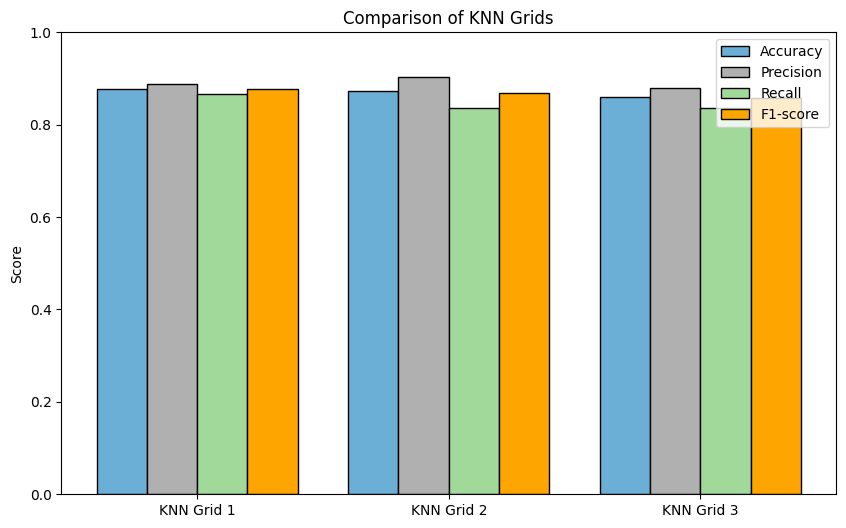

In [21]:
plt.figure(figsize=(10,6))

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = range(len(df_knn))
width = 0.2

# Define different colors for each metric
colors = ['#6BAED6', '#B0B0B0', '#A1D99B', 'orange']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    plt.bar([p + width*i for p in x], df_knn[metric], width=width, label=metric, color=color, edgecolor='black')

plt.xticks([p + 1.5*width for p in x], df_knn["Model"])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Comparison of KNN Grids")
plt.legend()
plt.show()